# Face Emotion Detection - MobileNetV2 + MediaPipe/YOLO Updates




## 1. Install Libraries

Run this cell once per environment if the packages are not available.

In [1]:
!pip install -q kagglehub tensorflow opencv-python scikit-learn matplotlib pandas pillow mediapipe


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 8.6 MB/s eta 0:00:00


## 2. Imports and Project Paths

In [2]:
import json
import os
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers

try:
    import kagglehub
except ImportError:
    kagglehub = None

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'data').exists() else NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
MODEL_DIR = ARTIFACTS_DIR / 'models'
OUTPUT_DIR = ARTIFACTS_DIR / 'outputs'
UPLOAD_DIR = OUTPUT_DIR / 'uploaded_images'

for path in [RAW_DIR, PROCESSED_DIR, MODEL_DIR, OUTPUT_DIR, UPLOAD_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('TensorFlow:', tf.__version__)
print('MediaPipe:', mp.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))
print('Project root:', PROJECT_ROOT)
print('Raw data dir:', RAW_DIR)
print('Model dir:', MODEL_DIR)


TensorFlow: 2.20.0
MediaPipe: 0.10.35
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Project root: /
Raw data dir: /data/raw
Model dir: /artifacts/models


In [3]:
# Demo helper functions for visualization
def show_image_grid(dataframe, samples_per_class=4, title='Samples by class'):
    if dataframe.empty:
        print('No images to display.')
        return

    rows = []
    for label in CLASS_NAMES:
        subset = dataframe[dataframe['label'] == label]
        if subset.empty:
            continue
        rows.append(subset.sample(min(samples_per_class, len(subset)), random_state=SEED))

    sample_df = pd.concat(rows).reset_index(drop=True)
    ncols = samples_per_class
    nrows = len(sample_df['label'].unique())
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.4, nrows * 2.4))
    axes = np.asarray(axes).reshape(nrows, ncols)

    for ax in axes.ravel():
        ax.axis('off')

    for row_idx, label in enumerate(sample_df['label'].unique()):
        label_df = sample_df[sample_df['label'] == label].reset_index(drop=True)
        for col_idx, item in label_df.iterrows():
            image = Image.open(item['path']).convert('RGB')
            axes[row_idx, col_idx].imshow(image)
            axes[row_idx, col_idx].set_title(label, fontsize=10)
            axes[row_idx, col_idx].axis('off')

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


## 3. Configuration

If  AffectNet have extracted locally, point `LOCAL_DATASET_ROOTS` to that folder. If `data/raw` already contains dataset folders, the notebook will use them automatically and skip downloading.

In [4]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_HEAD = 20
EPOCHS_FINE_TUNE = 25
VALID_SIZE = 0.15
TEST_SIZE = 0.15
LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINE = 1e-5
USE_MIXED_PRECISION = True
COPY_DATASETS_TO_RAW = False

KAGGLE_DATASETS = ['mstjebashazida/affectnet','fatihkgg/affectnet-yolo-format']
LOCAL_DATASET_ROOTS = []

CLASS_NAMES = ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

AFFECTNET_ID_TO_LABEL = {
    0: 'anger',
    1: 'contempt',
    2: 'disgust',
    3: 'fear',
    4: 'happy',
    5: 'neutral',
    6: 'sad',
    7: 'surprise',
}

LABEL_ALIASES = {
    'anger': 'anger', 'angry': 'anger', 'angriness': 'anger',
    'angry_face': 'anger', 'angryface': 'anger', 'mad': 'anger',
    'contempt': 'contempt', 'contemptuous': 'contempt',
    'disgust': 'disgust', 'disgusted': 'disgust', 'disgusting': 'disgust',
    'fear': 'fear', 'fearful': 'fear', 'scared': 'fear', 'afraid': 'fear',
    'happy': 'happy', 'happiness': 'happy', 'joy': 'happy', 'joyful': 'happy',
    'smile': 'happy', 'smiling': 'happy',
    'neutral': 'neutral', 'normal': 'neutral', 'calm': 'neutral',
    'sad': 'sad', 'sadness': 'sad', 'unhappy': 'sad',
    'surprise': 'surprise', 'surprised': 'surprise', 'surprize': 'surprise',
}

AFFECTNET_LABEL_COLUMNS = [
    'expression', 'exp', 'emotion', 'label', 'class', 'category', 'emotion_label', 'expression_label'
]
AFFECTNET_PATH_COLUMNS = [
    'subDirectory_filePath', 'subdirectory_filepath', 'filepath', 'file_path', 'path', 'image', 'image_path', 'filename', 'file'
]

BEST_MODEL_PATH = MODEL_DIR / 'best_mobilenetv2_emotion_model.keras'
FINAL_MODEL_PATH = MODEL_DIR / 'face_emotion_mobilenetv2_mediapipe_v2.keras'
METADATA_PATH = MODEL_DIR / 'metadata_mobilenetv2_mediapipe_v2.json'

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

if USE_MIXED_PRECISION and tf.config.list_physical_devices('GPU'):
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision enabled.')
else:
    print('Mixed precision disabled.')


Mixed precision enabled.


## 4. Locate or Download Dataset

In [5]:
def is_colab_runtime():
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False


def is_kaggle_runtime():
    return Path('/kaggle/input').exists()


def find_kaggle_input_roots():
    input_dir = Path('/kaggle/input')
    if not input_dir.exists():
        return []
    return [p.resolve() for p in input_dir.iterdir() if p.is_dir()]


def find_local_raw_roots(raw_dir):
    if not raw_dir.exists():
        return []
    return [p.resolve() for p in raw_dir.iterdir() if p.is_dir()]


def prepare_kaggle_credentials():
    kaggle_dir = Path.home() / '.kaggle'
    kaggle_json = kaggle_dir / 'kaggle.json'
    if kaggle_json.exists() or os.environ.get('KAGGLE_USERNAME'):
        return

    if is_kaggle_runtime():
        print('Kaggle runtime detected. Prefer adding the dataset as an Input.')
        return

    if is_colab_runtime():
        print('Upload kaggle.json from your Kaggle account settings.')
        from google.colab import files  # type: ignore
        uploaded = files.upload()
        if 'kaggle.json' not in uploaded:
            raise FileNotFoundError('kaggle.json was not uploaded.')
        kaggle_dir.mkdir(parents=True, exist_ok=True)
        kaggle_json.write_bytes(uploaded['kaggle.json'])
        try:
            os.chmod(kaggle_json, 0o600)
        except OSError:
            pass
        return

    raise FileNotFoundError(
        'No Kaggle credentials found. Put kaggle.json in ~/.kaggle or set KAGGLE_USERNAME/KAGGLE_KEY.'
    )


def download_kaggle_datasets(dataset_slugs, raw_dir, copy_to_raw=False):
    if LOCAL_DATASET_ROOTS:
        roots = [Path(p).expanduser().resolve() for p in LOCAL_DATASET_ROOTS]
        missing = [str(p) for p in roots if not p.exists()]
        if missing:
            raise FileNotFoundError('LOCAL_DATASET_ROOTS not found: ' + ', '.join(missing))
        print('Using LOCAL_DATASET_ROOTS:', roots)
        return roots

    local_roots = find_local_raw_roots(raw_dir)
    if local_roots:
        print('Using dataset folders already present in data/raw:', local_roots)
        return local_roots

    kaggle_input_roots = find_kaggle_input_roots()
    if kaggle_input_roots:
        print('Using Kaggle Input roots:', kaggle_input_roots)
        return kaggle_input_roots

    if kagglehub is None:
        raise ImportError('kagglehub is not installed. Run the install cell first.')

    prepare_kaggle_credentials()

    downloaded_paths = []
    for slug in dataset_slugs:
        print(f'Downloading or locating Kaggle dataset: {slug}')
        dataset_path = Path(kagglehub.dataset_download(slug)).resolve()
        if copy_to_raw:
            target_path = raw_dir / slug.replace('/', '__')
            if target_path.exists():
                print('Target already exists, reusing:', target_path)
            else:
                import shutil
                shutil.copytree(dataset_path, target_path)
            dataset_path = target_path.resolve()
        downloaded_paths.append(dataset_path)
        print('Dataset root:', dataset_path)

    return downloaded_paths


dataset_roots = download_kaggle_datasets(
    KAGGLE_DATASETS,
    RAW_DIR,
    copy_to_raw=COPY_DATASETS_TO_RAW,
)
dataset_roots


Kaggle runtime detected. Prefer adding the dataset as an Input.
Using Colab cache for faster access to the 'affectnet' dataset.
Dataset root: /kaggle/input/affectnet
Using Colab cache for faster access to the 'affectnet-yolo-format' dataset.
Dataset root: /kaggle/input/affectnet-yolo-format


[PosixPath('/kaggle/input/affectnet'),
 PosixPath('/kaggle/input/affectnet-yolo-format')]

## 5. Normalize Labels and Build the Index

In [6]:
def normalize_label(value, numeric_mapping='affectnet'):
    if pd.isna(value):
        return None

    text = str(value).strip().lower().replace(' ', '_')
    if text in {'', 'nan', 'none', 'uncertain', 'non_face', 'non-face'}:
        return None

    try:
        numeric = int(float(text))
        if numeric_mapping == 'affectnet':
            return AFFECTNET_ID_TO_LABEL.get(numeric)
    except ValueError:
        pass

    return LABEL_ALIASES.get(text)


def infer_label_from_path(path):
    parts = [p.lower().replace(' ', '_') for p in Path(path).parts]
    for part in reversed(parts):
        label = normalize_label(part, numeric_mapping='affectnet')
        if label is not None:
            return label
    return None


def first_matching_column(columns, candidates):
    normalized = {str(col).strip().lower(): col for col in columns}
    for candidate in candidates:
        if candidate.lower() in normalized:
            return normalized[candidate.lower()]
    return None


def find_existing_image(root, value):
    candidate = Path(str(value).strip())
    candidates = []
    if candidate.is_absolute():
        candidates.append(candidate)
    else:
        clean_value = str(value).strip().lstrip('/\\')
        candidates.extend([
            Path(root) / candidate,
            Path(root) / clean_value,
            Path(root) / 'Manually_Annotated' / 'Manually_Annotated_Images' / clean_value,
            Path(root) / 'Automatically_Annotated' / 'Automatically_Annotated_Images' / clean_value,
        ])

    for item in candidates:
        if item.exists() and item.suffix.lower() in IMAGE_EXTS:
            return item.resolve()
    return None


def collect_affectnet_csv_records(root):
    records = []
    for csv_path in Path(root).rglob('*.csv'):
        try:
            sample = pd.read_csv(csv_path, nrows=5)
        except Exception:
            continue

        path_col = first_matching_column(sample.columns, AFFECTNET_PATH_COLUMNS)
        label_col = first_matching_column(sample.columns, AFFECTNET_LABEL_COLUMNS)
        if path_col is None or label_col is None:
            continue

        print('Reading AffectNet annotations:', csv_path)
        for chunk in pd.read_csv(csv_path, usecols=[path_col, label_col], chunksize=50000):
            chunk = chunk.dropna(subset=[path_col, label_col])
            for row in chunk.itertuples(index=False):
                image_value, label_value = row
                label = normalize_label(label_value, numeric_mapping='affectnet')
                if label is None:
                    continue
                image_path = find_existing_image(root, image_value)
                if image_path is None:
                    continue
                records.append({
                    'path': str(image_path),
                    'label': label,
                    'source': Path(root).name,
                    'annotation_file': csv_path.name,
                })
    return records


def collect_folder_label_records(root):
    records = []
    for file_path in Path(root).rglob('*'):
        if file_path.suffix.lower() not in IMAGE_EXTS:
            continue
        label = infer_label_from_path(file_path.relative_to(root))
        if label is not None:
            records.append({
                'path': str(file_path.resolve()),
                'label': label,
                'source': Path(root).name,
                'annotation_file': None,
            })
    return records


def parse_yolo_names(root):
    """Read YOLO class names from data.yaml. Falls back to CLASS_NAMES order."""
    import ast
    import re

    yaml_files = list(Path(root).rglob('data.yaml')) + list(Path(root).rglob('*.yaml'))
    for yaml_path in yaml_files:
        text = yaml_path.read_text(encoding='utf-8', errors='ignore')
        lines = text.splitlines()

        inline = re.search(r'^\s*names\s*:\s*(\[.*\]|\{.*\})\s*$', text, flags=re.MULTILINE)
        if inline:
            try:
                value = ast.literal_eval(inline.group(1))
                if isinstance(value, dict):
                    names = [value[i] for i in sorted(value)]
                else:
                    names = list(value)
                return [normalize_label(name) or str(name).strip().lower() for name in names]
            except Exception:
                pass

        for idx, line in enumerate(lines):
            if line.strip().startswith('names:'):
                names = []
                for child in lines[idx + 1:]:
                    if not child.startswith((' ', '\t', '-')):
                        break
                    cleaned = child.strip().strip(',')
                    if not cleaned:
                        continue
                    if ':' in cleaned:
                        cleaned = cleaned.split(':', 1)[1].strip()
                    if cleaned.startswith('-'):
                        cleaned = cleaned[1:].strip()
                    cleaned = cleaned.strip('"\'')
                    label = normalize_label(cleaned) or cleaned.lower().replace(' ', '_')
                    if label:
                        names.append(label)
                if names:
                    return names

    return CLASS_NAMES


def yolo_label_path_for_image(image_path):
    image_path = Path(image_path)
    parts = list(image_path.parts)
    label_candidates = []

    if 'images' in parts:
        idx = parts.index('images')
        label_parts = parts.copy()
        label_parts[idx] = 'labels'
        label_candidates.append(Path(*label_parts).with_suffix('.txt'))

    label_candidates.append(image_path.with_suffix('.txt'))
    label_candidates.append(image_path.parent.parent / 'labels' / image_path.parent.name / f'{image_path.stem}.txt')
    label_candidates.append(image_path.parent.parent / 'labels' / f'{image_path.stem}.txt')

    for candidate in label_candidates:
        if candidate.exists():
            return candidate
    return None


def crop_yolo_box(image, x_center, y_center, width, height, margin=0.12):
    img_w, img_h = image.size
    x1 = (x_center - width / 2) * img_w
    y1 = (y_center - height / 2) * img_h
    x2 = (x_center + width / 2) * img_w
    y2 = (y_center + height / 2) * img_h

    pad_x = (x2 - x1) * margin
    pad_y = (y2 - y1) * margin
    x1 = max(0, int(round(x1 - pad_x)))
    y1 = max(0, int(round(y1 - pad_y)))
    x2 = min(img_w, int(round(x2 + pad_x)))
    y2 = min(img_h, int(round(y2 + pad_y)))

    if x2 <= x1 or y2 <= y1:
        return None
    return image.crop((x1, y1, x2, y2))


def collect_yolo_records(root):
    root = Path(root)
    yolo_names = parse_yolo_names(root)
    label_files = list(root.rglob('labels/**/*.txt')) + list(root.rglob('labels/*.txt'))
    if not label_files:
        label_files = [p for p in root.rglob('*.txt') if p.name.lower() not in {'classes.txt', 'readme.txt'}]
    if not label_files:
        return []

    print('YOLO class names:', yolo_names)
    crop_root = PROCESSED_DIR / 'yolo_crops' / root.name
    records = []
    image_lookup = {p.with_suffix('').as_posix().lower(): p for p in root.rglob('*') if p.suffix.lower() in IMAGE_EXTS}

    for label_path in label_files:
        possible_keys = []
        if 'labels' in label_path.parts:
            parts = list(label_path.parts)
            idx = parts.index('labels')
            image_parts = parts.copy()
            image_parts[idx] = 'images'
            possible_keys.append(Path(*image_parts).with_suffix('').as_posix().lower())
        possible_keys.append(label_path.with_suffix('').as_posix().lower())

        image_path = None
        for key in possible_keys:
            image_path = image_lookup.get(key)
            if image_path is not None:
                break

        if image_path is None:
            stem_matches = [p for p in image_lookup.values() if p.stem == label_path.stem]
            if len(stem_matches) == 1:
                image_path = stem_matches[0]

        if image_path is None:
            continue

        try:
            image = Image.open(image_path).convert('RGB')
        except Exception:
            continue

        for box_idx, line in enumerate(label_path.read_text(encoding='utf-8', errors='ignore').splitlines()):
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            try:
                class_id = int(float(parts[0]))
                x_center, y_center, width, height = map(float, parts[1:5])
            except ValueError:
                continue
            if class_id < 0 or class_id >= len(yolo_names):
                continue

            label = normalize_label(yolo_names[class_id]) or yolo_names[class_id]
            if label not in CLASS_NAMES:
                continue

            crop = crop_yolo_box(image, x_center, y_center, width, height)
            if crop is None:
                continue

            split_name = 'unknown'
            lower_parts = [p.lower() for p in image_path.parts]
            for candidate in ['train', 'valid', 'val', 'test']:
                if candidate in lower_parts:
                    split_name = 'valid' if candidate == 'val' else candidate
                    break

            target_dir = crop_root / split_name / label
            target_dir.mkdir(parents=True, exist_ok=True)
            target_path = target_dir / f'{image_path.stem}_{box_idx}.jpg'
            if not target_path.exists():
                crop.resize(IMG_SIZE).save(target_path, quality=95)

            records.append({
                'path': str(target_path.resolve()),
                'label': label,
                'source': root.name,
                'annotation_file': str(label_path.relative_to(root)),
            })

    if records:
        print(f'YOLO records created from {root}: {len(records)}')
        print('YOLO crops saved to:', crop_root)
    return records


def collect_image_files(dataset_roots):
    records = []
    for root in dataset_roots:
        root = Path(root)
        csv_records = collect_affectnet_csv_records(root)
        if csv_records:
            records.extend(csv_records)
            continue

        yolo_records = collect_yolo_records(root)
        if yolo_records:
            records.extend(yolo_records)
            continue

        records.extend(collect_folder_label_records(root))

    df_images = pd.DataFrame(records)
    if df_images.empty:
        return pd.DataFrame(columns=['path', 'label', 'source', 'annotation_file'])

    df_images = df_images.drop_duplicates('path').reset_index(drop=True)
    df_images = df_images[df_images['label'].isin(CLASS_NAMES)].copy()
    df_images['label_id'] = df_images['label'].map(CLASS_TO_ID)
    return df_images


df_images = collect_image_files(dataset_roots)
print('Images found:', len(df_images))
display(df_images['label'].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int))
df_images.head()


YOLO class names: ['[', 'anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise', ']']
YOLO records created from /kaggle/input/affectnet-yolo-format: 43656
YOLO crops saved to: /data/processed/yolo_crops/affectnet-yolo-format
Images found: 52454


,count
label,
anger,6164
contempt,6112
disgust,5438
fear,6520
happy,7424
neutral,7921
sad,8836
surprise,4039


,path,label,source,annotation_file,label_id
0,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,7
1,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,7
2,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,7
3,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,7
4,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,7


## 5.1 Data Preview

Run these cells before training to inspect the dataset that was found.

Total images: 52454


,emotion,count,percent
0,anger,6164,11.751249
1,contempt,6112,11.652114
2,disgust,5438,10.367179
3,fear,6520,12.429939
4,happy,7424,14.153353
5,neutral,7921,15.100850
6,sad,8836,16.845236
7,surprise,4039,7.700080


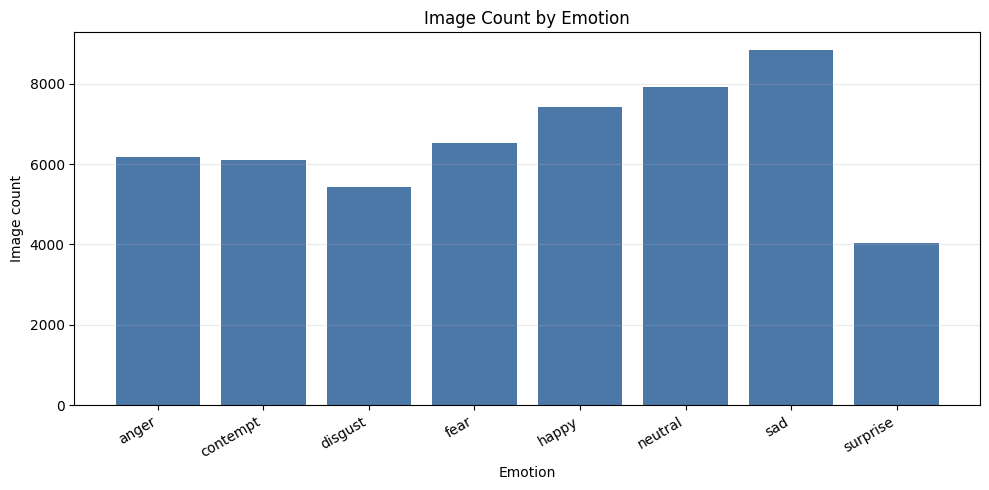

In [7]:
print('Total images:', len(df_images))
if not df_images.empty:
    overview = df_images['label'].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int).reset_index()
    overview.columns = ['emotion', 'count']
    overview['percent'] = overview['count'] / overview['count'].sum() * 100
    display(overview)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(overview['emotion'], overview['count'], color='#4C78A8')
    ax.set_title('Image Count by Emotion')
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Image count')
    ax.grid(axis='y', alpha=0.25)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


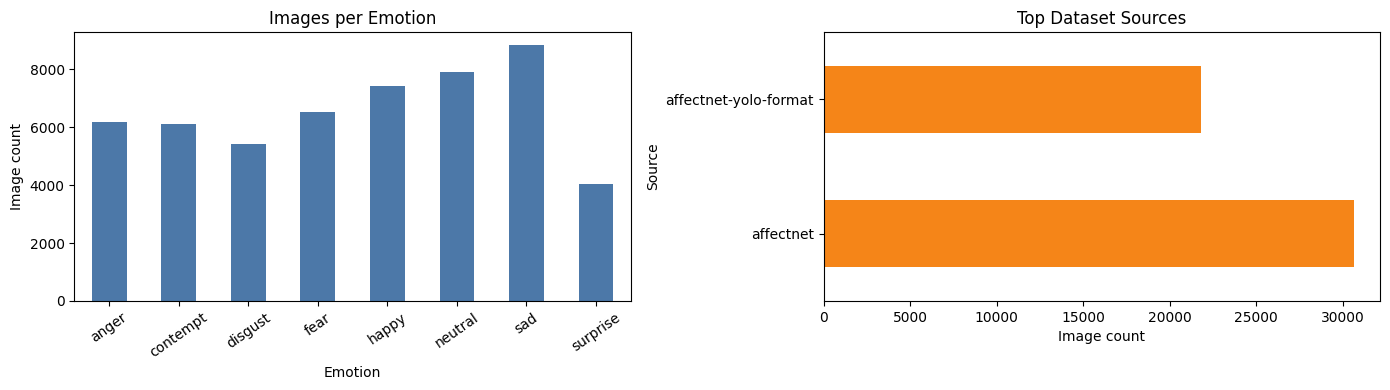

In [8]:
if df_images.empty:
    print('No images to plot.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    label_counts = df_images['label'].value_counts().reindex(CLASS_NAMES).fillna(0)
    label_counts.plot(kind='bar', ax=axes[0], color='#4C78A8')
    axes[0].set_title('Images per Emotion')
    axes[0].set_xlabel('Emotion')
    axes[0].set_ylabel('Image count')
    axes[0].tick_params(axis='x', rotation=35)

    source_counts = df_images['source'].value_counts().head(10)
    source_counts.plot(kind='barh', ax=axes[1], color='#F58518')
    axes[1].set_title('Top Dataset Sources')
    axes[1].set_xlabel('Image count')
    axes[1].set_ylabel('Source')

    plt.tight_layout()
    plt.show()

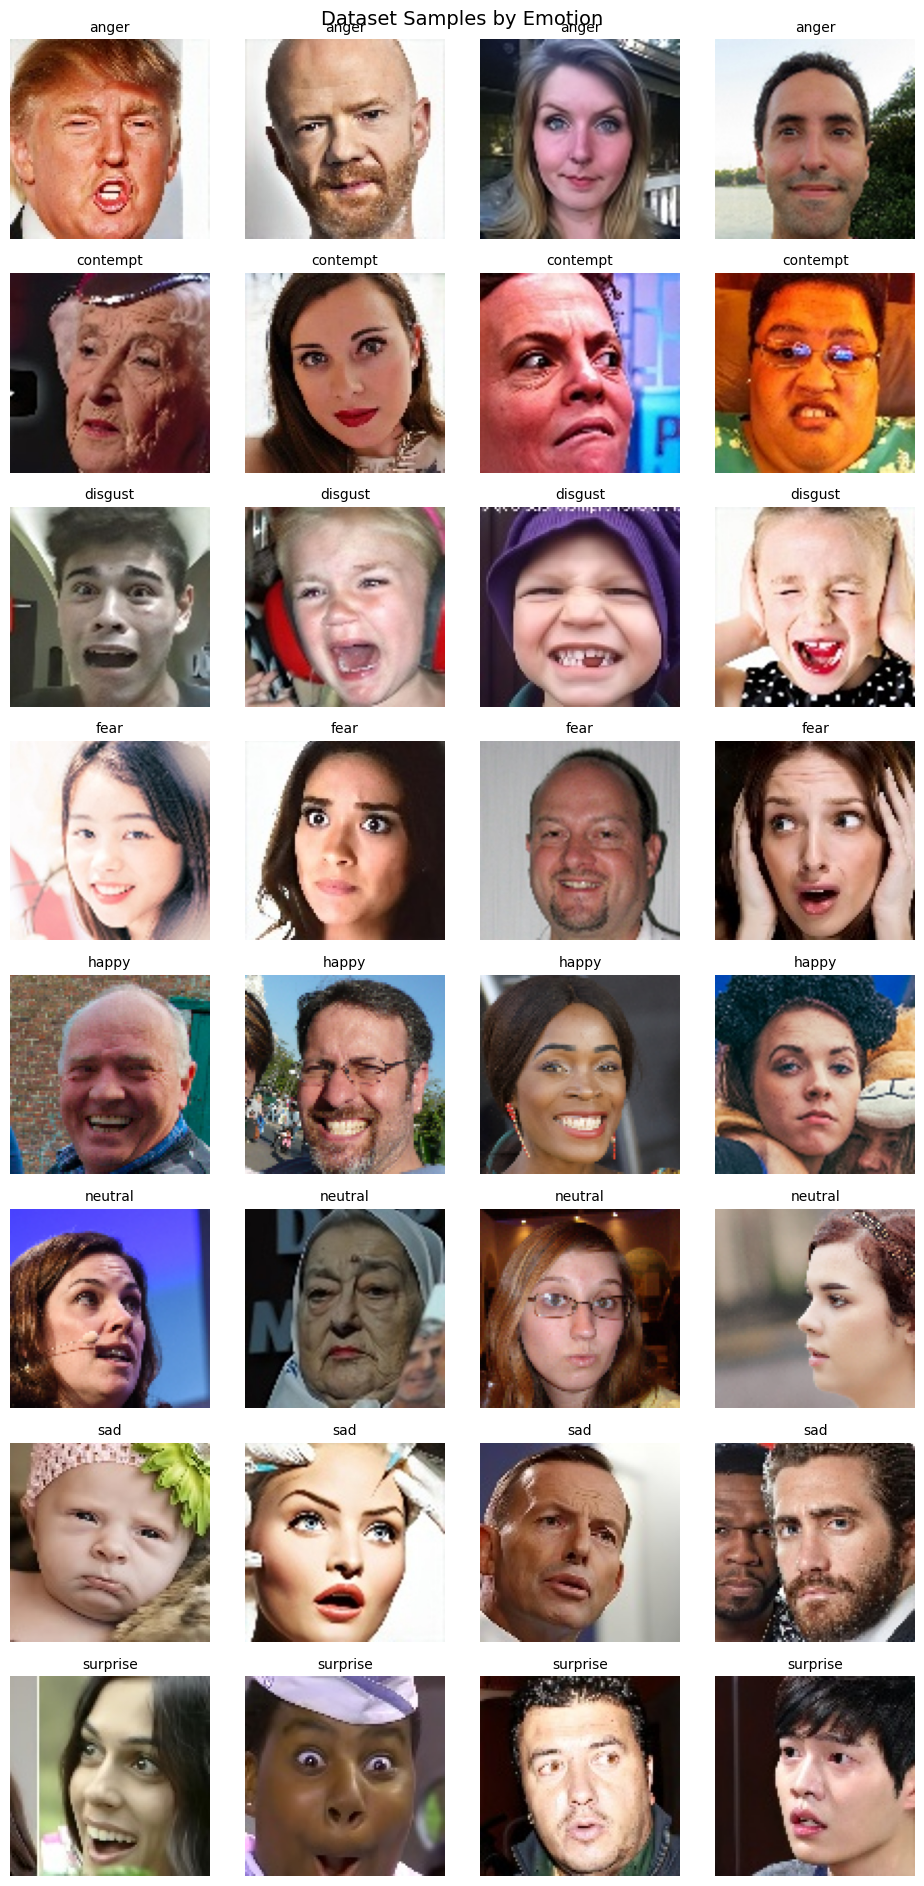

In [9]:
show_image_grid(df_images, samples_per_class=4, title='Dataset Samples by Emotion')


## 6. Train / Validation / Test Split

36717 7868 7869


,train,valid,test
label,,,
anger,4315,925,924
contempt,4278,917,917
disgust,3806,816,816
fear,4564,978,978
happy,5197,1113,1114
neutral,5545,1188,1188
sad,6185,1325,1326
surprise,2827,606,606


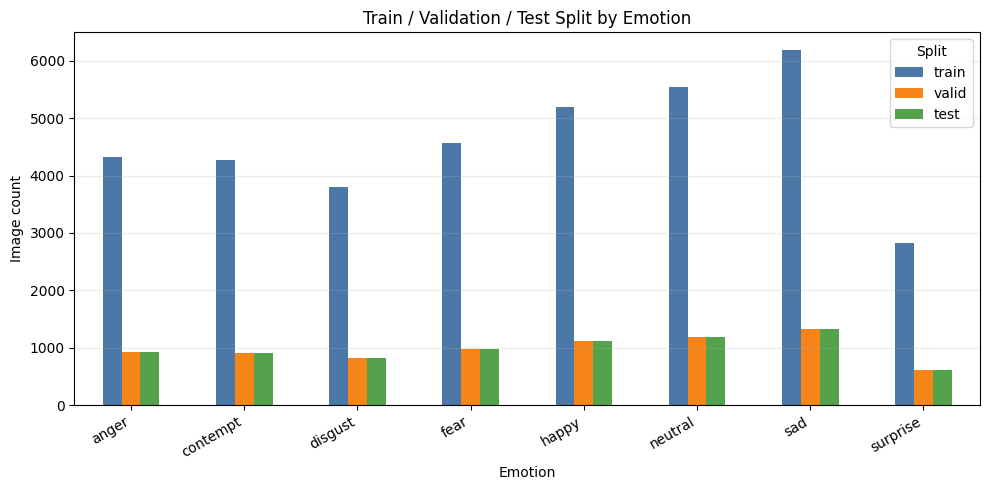

Saved split CSV files to: /data/processed


In [10]:
if df_images.empty:
    raise ValueError('No valid AffectNet data found.')

min_class_count = int(df_images['label'].value_counts().min())
if min_class_count < 2:
    raise ValueError('Each class needs at least 2 samples for stratified splitting.')

train_df, temp_df = train_test_split(
    df_images,
    test_size=VALID_SIZE + TEST_SIZE,
    stratify=df_images['label'],
    random_state=SEED,
)

relative_test = TEST_SIZE / (VALID_SIZE + TEST_SIZE)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test,
    stratify=temp_df['label'],
    random_state=SEED,
)

split_summary = pd.DataFrame({
    'train': train_df['label'].value_counts(),
    'valid': valid_df['label'].value_counts(),
    'test': test_df['label'].value_counts(),
}).reindex(CLASS_NAMES).fillna(0).astype(int)

print(len(train_df), len(valid_df), len(test_df))
display(split_summary)

fig, ax = plt.subplots(figsize=(10, 5))
split_summary.plot(kind='bar', ax=ax, color=['#4C78A8', '#F58518', '#54A24B'])
ax.set_title('Train / Validation / Test Split by Emotion')
ax.set_xlabel('Emotion')
ax.set_ylabel('Image count')
ax.legend(title='Split')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

train_df.to_csv(PROCESSED_DIR / 'train_split_v2.csv', index=False)
valid_df.to_csv(PROCESSED_DIR / 'valid_split_v2.csv', index=False)
test_df.to_csv(PROCESSED_DIR / 'test_split_v2.csv', index=False)
print('Saved split CSV files to:', PROCESSED_DIR)


## 7. TensorFlow Datasets

Class weights: {0: 1.0636442641946697, 1: 1.0728436185133239, 2: 1.205892012611666, 3: 1.005614592462752, 4: 0.883129690205888, 5: 0.8277051397655546, 6: 0.7420573969280517, 7: 1.6234966395472232}


,emotion,class_weight,train_count
0,anger,1.063644,4315
1,contempt,1.072844,4278
2,disgust,1.205892,3806
3,fear,1.005615,4564
4,happy,0.883130,5197
5,neutral,0.827705,5545
6,sad,0.742057,6185
7,surprise,1.623497,2827


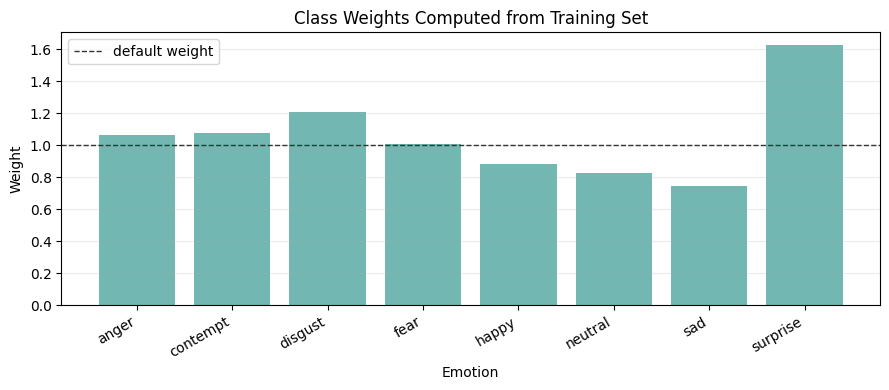

In [11]:
AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label


def make_dataset(dataframe, training=False):
    paths = dataframe['path'].astype(str).values
    labels = dataframe['label_id'].astype(np.int32).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(min(len(dataframe), 10000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, training=True)
valid_ds = make_dataset(valid_df)
test_ds = make_dataset(test_df)

present_train_classes = np.sort(train_df['label_id'].unique()).astype(int)
missing_train_classes = sorted(set(range(len(CLASS_NAMES))) - set(present_train_classes.tolist()))
if missing_train_classes:
    missing_names = [CLASS_NAMES[i] for i in missing_train_classes]
    print('Warning: these classes are missing from train_df and will use default weight 1.0:', missing_names)

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=present_train_classes,
    y=train_df['label_id'].values,
)
class_weights = {i: 1.0 for i in range(len(CLASS_NAMES))}
class_weights.update({int(cls): float(weight) for cls, weight in zip(present_train_classes, class_weights_arr)})
print('Class weights:', class_weights)

class_weight_df = pd.DataFrame({
    'emotion': CLASS_NAMES,
    'class_weight': [class_weights[i] for i in range(len(CLASS_NAMES))],
    'train_count': [int((train_df['label_id'] == i).sum()) for i in range(len(CLASS_NAMES))],
})
display(class_weight_df)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(class_weight_df['emotion'], class_weight_df['class_weight'], color='#72B7B2')
ax.axhline(1.0, color='#333333', linewidth=1, linestyle='--', label='default weight')
ax.set_title('Class Weights Computed from Training Set')
ax.set_xlabel('Emotion')
ax.set_ylabel('Weight')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 8. Build and Train the Model

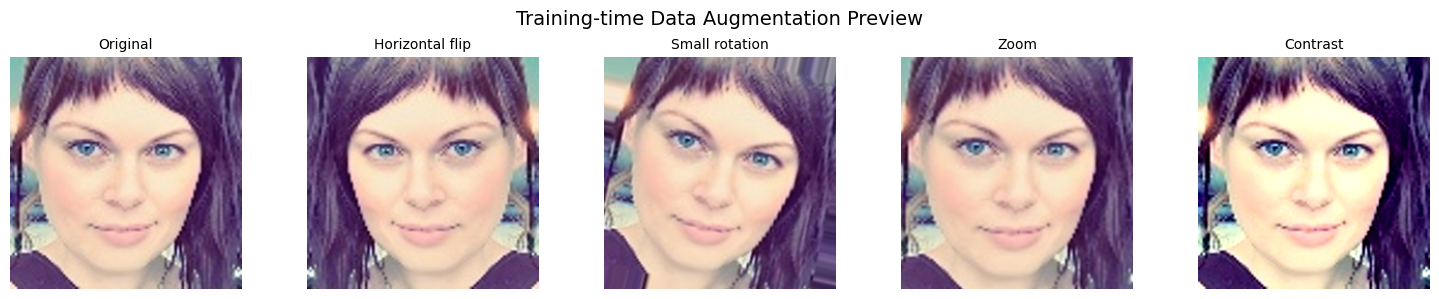

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV2_Emotion_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

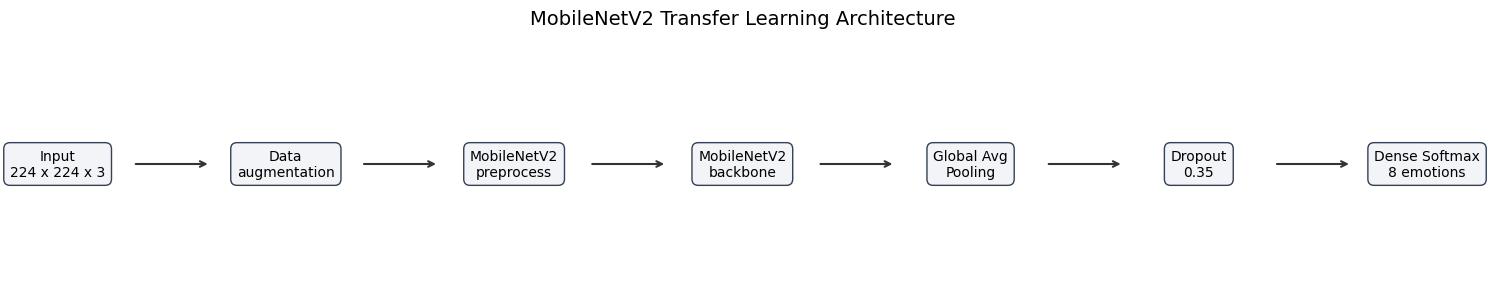

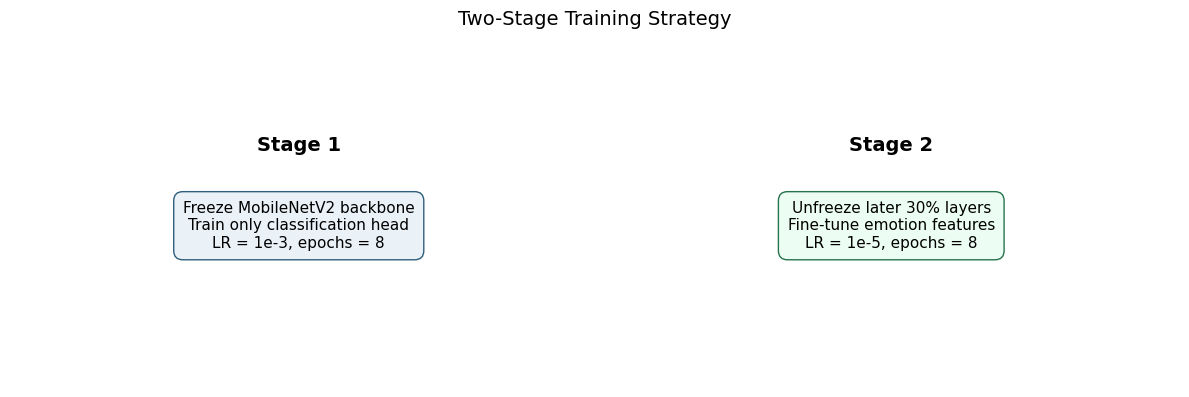

Epoch 1/20
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1976 - loss: 2.1922
Epoch 1: val_accuracy improved from None to 0.28317, saving model to /artifacts/models/best_mobilenetv2_emotion_model.keras

Epoch 1: finished saving model to /artifacts/models/best_mobilenetv2_emotion_model.keras
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 149s 108ms/step - accuracy: 0.2265 - loss: 2.0703 - val_accuracy: 0.2832 - val_loss: 1.8457 - learning_rate: 0.0010
Epoch 2/20
1147/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2592 - loss: 1.9566
Epoch 2: val_accuracy improved from 0.28317 to 0.29131, saving model to /artifacts/models/best_mobilenetv2_emotion_model.keras

Epoch 2: finished saving model to /artifacts/models/best_mobilenetv2_emotion_model.keras
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 79s 69ms/step - accuracy: 0.2608 - loss: 1.9454 - val_accuracy: 0.2913 - val_loss: 1.8082 - learning_rate: 0.0010
Epoch 3/20
1147/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2619 - loss: 1.9237
Epoch 3: v

In [12]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='augmentation')

preview_row = train_df.sample(1, random_state=SEED).iloc[0]
preview_image = keras.utils.load_img(preview_row['path'], target_size=IMG_SIZE)
preview_array = keras.utils.img_to_array(preview_image)

augmentation_examples = [
    ('Original', preview_array),
    ('Horizontal flip', tf.image.flip_left_right(preview_array).numpy()),
    ('Small rotation', layers.RandomRotation(0.08, fill_mode='nearest', seed=SEED)(preview_array[None, ...], training=True)[0].numpy()),
    ('Zoom', layers.RandomZoom(0.10, fill_mode='nearest', seed=SEED)(preview_array[None, ...], training=True)[0].numpy()),
    ('Contrast', tf.image.adjust_contrast(preview_array, 1.4).numpy()),
]

fig, axes = plt.subplots(1, len(augmentation_examples), figsize=(15, 3))
for ax, (title, image) in zip(axes, augmentation_examples):
    ax.imshow(np.clip(image, 0, 255).astype('uint8'))
    ax.set_title(title, fontsize=10)
    ax.axis('off')
fig.suptitle('Training-time Data Augmentation Preview', fontsize=14)
fig.tight_layout()
plt.show()

base_model = keras.applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SIZE + (3,),
)
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation='softmax', dtype='float32')(x)

model = keras.Model(inputs, outputs, name='MobileNetV2_Emotion_Classifier')
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_HEAD),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

callbacks = [
    keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=8,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

architecture_steps = [
    'Input\n224 x 224 x 3',
    'Data\naugmentation',
    'MobileNetV2\npreprocess',
    'MobileNetV2\nbackbone',
    'Global Avg\nPooling',
    'Dropout\n0.35',
    'Dense Softmax\n8 emotions',
]
fig, ax = plt.subplots(figsize=(15, 3))
ax.axis('off')
for i, step in enumerate(architecture_steps):
    x = i / (len(architecture_steps) - 1)
    ax.text(x, 0.5, step, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.45', facecolor='#F2F4F7', edgecolor='#344054'))
    if i < len(architecture_steps) - 1:
        next_x = (i + 1) / (len(architecture_steps) - 1)
        ax.annotate('', xy=(next_x - 0.055, 0.5), xytext=(x + 0.055, 0.5),
                    arrowprops=dict(arrowstyle='->', linewidth=1.5, color='#333333'))
ax.set_title('MobileNetV2 Transfer Learning Architecture', fontsize=14, pad=18)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax in axes:
    ax.axis('off')
axes[0].text(0.5, 0.72, 'Stage 1', ha='center', va='center', fontsize=14, weight='bold')
axes[0].text(0.5, 0.48, 'Freeze MobileNetV2 backbone\nTrain only classification head\nLR = 1e-3, epochs = 8',
             ha='center', va='center', fontsize=11,
             bbox=dict(boxstyle='round,pad=0.6', facecolor='#EAF2F8', edgecolor='#2F5D7C'))
axes[1].text(0.5, 0.72, 'Stage 2', ha='center', va='center', fontsize=14, weight='bold')
axes[1].text(0.5, 0.48, 'Unfreeze later 30% layers\nFine-tune emotion features\nLR = 1e-5, epochs = 8',
             ha='center', va='center', fontsize=11,
             bbox=dict(boxstyle='round,pad=0.6', facecolor='#ECFDF3', edgecolor='#26734D'))
fig.suptitle('Two-Stage Training Strategy', fontsize=14)
plt.tight_layout()
plt.show()

history_head = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks,
    class_weight=class_weights,
)

base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.70)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_FINE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history_fine = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=callbacks,
    class_weight=class_weights,
)


## 9. Evaluate and Save Artifacts

246/246 ━━━━━━━━━━━━━━━━━━━━ 39s 148ms/step - accuracy: 0.6143 - loss: 1.0582
Test loss: 1.0582
Test accuracy: 0.6143
              precision    recall  f1-score   support

       anger       0.58      0.60      0.59       924
    contempt       0.57      0.58      0.58       917
     disgust       0.51      0.51      0.51       816
        fear       0.65      0.59      0.62       978
       happy       0.72      0.71      0.71      1114
     neutral       0.71      0.71      0.71      1188
         sad       0.60      0.59      0.59      1326
    surprise       0.50      0.58      0.54       606

    accuracy                           0.61      7869
   macro avg       0.60      0.61      0.61      7869
weighted avg       0.62      0.61      0.61      7869



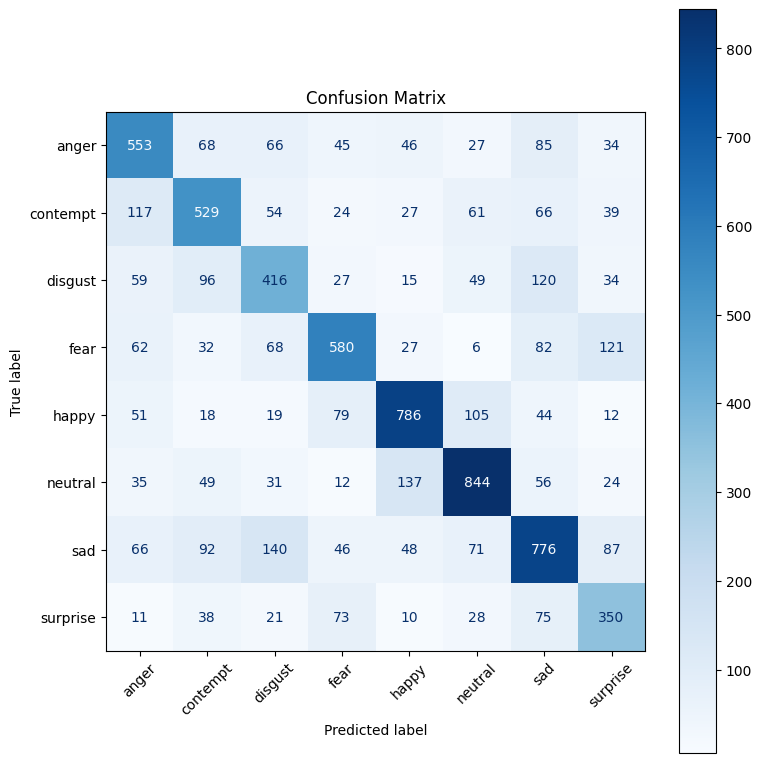

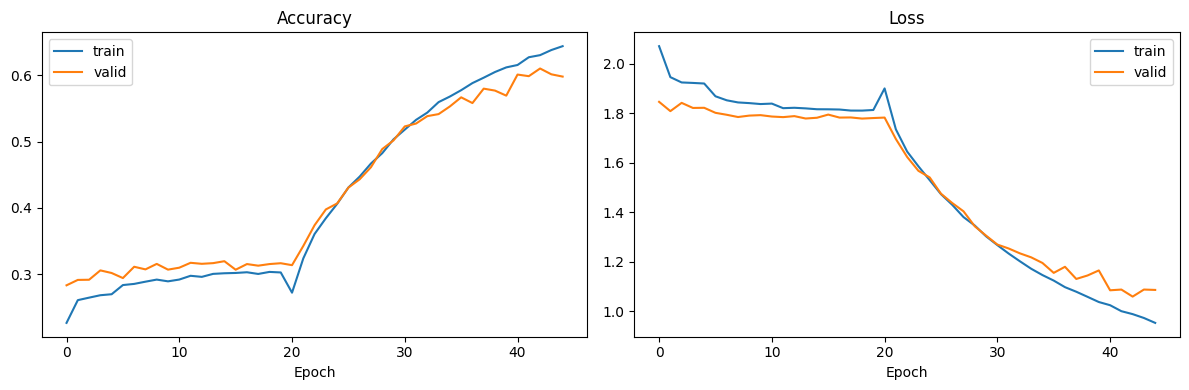

Saved model: /artifacts/models/face_emotion_mobilenetv2_mediapipe_v2.keras
Saved metadata: /artifacts/models/metadata_mobilenetv2_mediapipe_v2.json


In [13]:
def merge_history(*histories):
    merged = {}
    for hist in histories:
        for key, values in hist.history.items():
            merged.setdefault(key, []).extend(values)
    return merged


best_model = keras.models.load_model(BEST_MODEL_PATH)
test_loss, test_acc = best_model.evaluate(test_ds)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

y_true = []
y_pred = []
for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(probs, axis=1).tolist())

all_label_ids = list(range(len(CLASS_NAMES)))
print(classification_report(
    y_true,
    y_pred,
    labels=all_label_ids,
    target_names=CLASS_NAMES,
    zero_division=0,
))

cm = confusion_matrix(y_true, y_pred, labels=all_label_ids)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

hist = merge_history(history_head, history_fine)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hist['accuracy'], label='train')
plt.plot(hist['val_accuracy'], label='valid')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist['loss'], label='train')
plt.plot(hist['val_loss'], label='valid')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

best_model.save(FINAL_MODEL_PATH)

source_counts = df_images['source'].value_counts().to_dict()
label_counts = df_images['label'].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int).to_dict()
label_counts_by_source = (
    df_images
    .groupby(['source', 'label'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_NAMES, fill_value=0)
    .astype(int)
    .to_dict(orient='index')
)

metadata = {
    'model_name': 'MobileNetV2',
    'class_names': CLASS_NAMES,
    'img_size': IMG_SIZE,
    'requested_kaggle_datasets': KAGGLE_DATASETS,
    'local_dataset_roots_config': [str(p) for p in LOCAL_DATASET_ROOTS],
    'dataset_roots_used': [str(p) for p in dataset_roots],
    'dataset_root_count': int(len(dataset_roots)),
    'source_counts': {str(k): int(v) for k, v in source_counts.items()},
    'label_counts': {str(k): int(v) for k, v in label_counts.items()},
    'label_counts_by_source': {
        str(source): {str(label): int(count) for label, count in counts.items()}
        for source, counts in label_counts_by_source.items()
    },
    'train_samples': int(len(train_df)),
    'valid_samples': int(len(valid_df)),
    'test_samples': int(len(test_df)),
    'test_accuracy': float(test_acc),
    'class_weights': {str(k): float(v) for k, v in class_weights.items()},
    'face_detector': 'MediaPipe Face Detection',
}

with open(METADATA_PATH, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print('Saved model:', FINAL_MODEL_PATH)
print('Saved metadata:', METADATA_PATH)


## 9.1 Download Model and Metadata


In [14]:
def download_training_artifacts(
    model_path=FINAL_MODEL_PATH,
    metadata_path=METADATA_PATH,
    include_best_model=True,
    best_model_path=BEST_MODEL_PATH,
    zip_name='face_emotion_mobilenetv2_mediapipe_v2_artifacts.zip',
):
    import zipfile
    from pathlib import Path

    artifact_paths = [Path(model_path), Path(metadata_path)]
    if include_best_model:
        artifact_paths.append(Path(best_model_path))

    existing_paths = []
    missing_paths = []
    for artifact_path in artifact_paths:
        if artifact_path.exists():
            existing_paths.append(artifact_path)
        else:
            missing_paths.append(artifact_path)

    if missing_paths:
        print('Missing artifacts:')
        for missing_path in missing_paths:
            print('-', missing_path)

    if not existing_paths:
        raise FileNotFoundError('No artifacts found to download. Train and save the model first.')

    zip_path = Path(zip_name)
    with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zip_file:
        for artifact_path in existing_paths:
            zip_file.write(artifact_path, arcname=artifact_path.name)

    print('Created download zip:', zip_path.resolve())
    print('Included files:')
    for artifact_path in existing_paths:
        print('-', artifact_path)

    try:
        from google.colab import files  # type: ignore
        files.download(str(zip_path))
    except ImportError:
        print('Not running on Colab. Download the zip manually from:', zip_path.resolve())

    return zip_path


# Run this after the Evaluate and Save Artifacts cell finishes.
# download_training_artifacts()


## 10. Single-Image Prediction and MediaPipe Face Detection


In [15]:
# Run this cell after training finishes or after uploading a saved model from Colab.
# If you open a fresh runtime, set MODEL_PATH and METADATA_FILE to your saved files.

MODEL_PATH = FINAL_MODEL_PATH
METADATA_FILE = METADATA_PATH

if not Path(MODEL_PATH).exists():
    raise FileNotFoundError(
        f'Model not found: {MODEL_PATH}. Train notebook first, or update MODEL_PATH to your saved .keras file.'
    )

best_model = keras.models.load_model(MODEL_PATH)

if Path(METADATA_FILE).exists():
    with open(METADATA_FILE, 'r', encoding='utf-8') as f:
        metadata = json.load(f)
    CLASS_NAMES = metadata['class_names']
    IMG_SIZE = tuple(metadata['img_size'])
else:
    print('Metadata file not found. Using CLASS_NAMES and IMG_SIZE from this notebook.')

print('Model loaded:', MODEL_PATH)
print('CLASS_NAMES:', CLASS_NAMES)
print('IMG_SIZE:', IMG_SIZE)


Model loaded: /artifacts/models/face_emotion_mobilenetv2_mediapipe_v2.keras
CLASS_NAMES: ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
IMG_SIZE: (224, 224)


In [16]:
from google.colab import files

# Upload an image when running on Colab:
# uploaded_image = files.upload()
# image_path = list(uploaded_image.keys())[0]

# Or set the image path directly:
image_path = '/content/bieucamcuaguongmat.jpg'
print('Image file:', image_path)

mp_face_detection = mp.solutions.face_detection


def predict_emotion(image_path, model=best_model):
    image = Image.open(image_path).convert('RGB').resize(IMG_SIZE)
    array = np.asarray(image, dtype=np.float32)[None, ...]

    probs = model.predict(array, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_label = CLASS_NAMES[pred_idx]
    confidence = float(probs[pred_idx])

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'{pred_label} - {confidence:.2%}')
    plt.show()

    result_df = pd.DataFrame({
        'emotion': CLASS_NAMES,
        'probability': probs,
    }).sort_values('probability', ascending=False)

    display(result_df)

    plt.figure(figsize=(7, 4))
    plt.bar(result_df['emotion'], result_df['probability'])
    plt.xlabel('Emotion')
    plt.ylabel('Probability')
    plt.title('Emotion Prediction Probabilities')
    plt.xticks(rotation=45)
    plt.show()

    return result_df


def mediapipe_bbox_to_pixels(relative_bbox, image_width, image_height, margin=0.18):
    x = int(relative_bbox.xmin * image_width)
    y = int(relative_bbox.ymin * image_height)
    w = int(relative_bbox.width * image_width)
    h = int(relative_bbox.height * image_height)

    pad_x = int(w * margin)
    pad_y = int(h * margin)
    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(image_width, x + w + pad_x)
    y2 = min(image_height, y + h + pad_y)
    return x1, y1, x2 - x1, y2 - y1


def detect_faces_and_predict(image_path, model=best_model, min_detection_confidence=0.5):
    bgr = cv2.imread(str(image_path))
    if bgr is None:
        raise FileNotFoundError(f'Cannot read image: {image_path}')

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    image_height, image_width = rgb.shape[:2]

    with mp_face_detection.FaceDetection(
        model_selection=1,
        min_detection_confidence=min_detection_confidence,
    ) as detector:
        detection_result = detector.process(rgb)

    detections = detection_result.detections or []
    print(f'Detected faces: {len(detections)}')

    results = []
    annotated = bgr.copy()

    for i, detection in enumerate(detections, start=1):
        bbox = detection.location_data.relative_bounding_box
        x, y, w, h = mediapipe_bbox_to_pixels(bbox, image_width, image_height)
        if w <= 0 or h <= 0:
            continue

        face_rgb = rgb[y:y+h, x:x+w]
        face_rgb = cv2.resize(face_rgb, IMG_SIZE)

        probs = model.predict(face_rgb[None, ...].astype(np.float32), verbose=0)[0]
        pred_idx = int(np.argmax(probs))
        pred_label = CLASS_NAMES[pred_idx]
        confidence = float(np.max(probs))
        detection_score = float(detection.score[0]) if detection.score else None

        results.append({
            'face_id': i,
            'emotion': pred_label,
            'confidence': confidence,
            'face_score': detection_score,
            'x': x,
            'y': y,
            'w': w,
            'h': h,
        })

        cv2.rectangle(annotated, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(
            annotated,
            f'{pred_label}: {confidence:.2f}',
            (x, max(y - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2,
        )

    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(annotated_rgb)
    plt.axis('off')
    plt.title('MediaPipe Face Detection and Emotion Prediction')
    plt.show()

    if results:
        results_df = pd.DataFrame(results)
        display(results_df)
        return results_df

    print('No face detected. Full-image prediction is shown below.')
    return pd.DataFrame(columns=['face_id', 'emotion', 'confidence', 'face_score', 'x', 'y', 'w', 'h'])


single_result = predict_emotion(image_path, model=best_model)
face_result = detect_faces_and_predict(image_path, model=best_model)


Image file: /content/bieucamcuaguongmat.jpg


AttributeError: module 'mediapipe' has no attribute 'solutions'